# Tutorial 3a — Subject-Specific Mask Warping

**Learning objectives**
1. Understand why a subject-specific, run-specific mask is preferred over a
   static group mask for MVPA feature extraction
2. Apply fMRIPrep's two-step MNI→T1w→func transform chain using ANTsPy
3. Visualise warped masks across runs and verify spatial alignment
4. Filter zero-variance voxels and compute a common intersection mask
5. Save per-run and intersection masks for use in Tutorial 3b (MVPA decoding)

---


## Section 0 — Setup

In [2]:
import os, sys, warnings
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image, plotting
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from fmri_helpers import (
    warp_group_mask_to_func, filter_mask_by_variance, track_runtime,
)

# ── Subject / paths ───────────────────────────────────────────────────────────
SUBJECT       = "sub-1"
USER          = os.getenv("USER")
DERIV_ROOT    = f"/scratch/alpine/{USER}/mvpa_workshop/ds000105/derivatives"
FMRIPREP_ROOT = f"{DERIV_ROOT}/fmriprep"
WARPED_DIR    = f"{DERIV_ROOT}/beta_weights/{SUBJECT}/warped_masks"
os.makedirs(WARPED_DIR, exist_ok=True)

# ── fMRIPrep transform paths (one per run) ────────────────────────────────────
N_RUNS = 12
func_ref_files = [
    f"{FMRIPREP_ROOT}/{SUBJECT}/func/{SUBJECT}_task-objectviewing_run-{r}_boldref.nii.gz"
    for r in range(1, N_RUNS + 1)
]
t1w_to_func_xfms = [
    f"{FMRIPREP_ROOT}/{SUBJECT}/func/{SUBJECT}_task-objectviewing_run-{r}_from-T1w_to-scanner_mode-image_xfm.txt"
    for r in range(1, N_RUNS + 1)
]
mni_to_t1w_xfm = (
    f"{FMRIPREP_ROOT}/{SUBJECT}/anat/"
    f"{SUBJECT}_from-MNI152NLin6Asym_to-T1w_mode-image_xfm.h5"
)
bold_paths = [
    f"{FMRIPREP_ROOT}/{SUBJECT}/func/"
    f"{SUBJECT}_task-objectviewing_run-{r}_space-T1w_desc-preproc_bold.nii.gz"
    for r in range(1, N_RUNS + 1)
]

# ── Group mask (MNI152 2 mm) ──────────────────────────────────────────────────
group_mask_mni = (
    "/pl/active/courses/2026_summer/neuroclass2026/masks/"
    "VisualTemporal_MNI152NLin6Asym_2mm_mask.nii.gz"
)

print(f"Group mask exists : {os.path.exists(group_mask_mni)}")
print(f"MNI→T1w xfm exists: {os.path.exists(mni_to_t1w_xfm)}")
print(f"Warp output dir   : {WARPED_DIR}")


Group mask exists : True
MNI→T1w xfm exists: True
Warp output dir   : /scratch/alpine/amhe4269/mvpa_workshop/ds000105/derivatives/beta_weights/sub-1/warped_masks


In [3]:
# Check whether ANTsPy is available.
# If not, mask warping will fall back to nilearn resampling (less accurate but functional).
try:
    import ants
    ANTS_AVAILABLE = True
    print(f"ANTsPy version : {ants.__version__}")
    print("Full two-step fMRIPrep warp will be used (MNI→T1w→func).")
except ImportError:
    ANTS_AVAILABLE = False
    print("ANTsPy not installed — falling back to nilearn resampling.")
    print("Install with:  pip install antspyx")


ANTsPy version : 0.6.3
Full two-step fMRIPrep warp will be used (MNI→T1w→func).


---
## Section 1 — What is MVPA?

Classical fMRI analysis asks: *"Is this region more active during condition A than B?"*
(univariate, mass-univariate, or ROI mean comparison).

**MVPA** asks instead: *"Does the spatial pattern of activation across this region
contain information that distinguishes condition A from B?"*

This is a fundamentally different and often more sensitive question because:
- A region can carry **distributed information** without a detectable mean change
- The classifier exploits the **co-variance structure** across voxels
- Even voxels with sub-threshold individual activation can contribute to decoding

### The pipeline

```
Beta images (1 per trial)
    → Feature matrix X  (n_trials × n_voxels)
    → [Optional] Feature selection  (e.g. ANOVA-F to keep top voxels)
    → SVM classifier
    → Leave-one-run-out cross-validation
    → Decoding accuracy, confusion matrix, importance map
```

### Support Vector Machine (SVM)

The SVM finds a **maximum-margin hyperplane** that separates classes in the
feature space. With a linear kernel, the decision boundary is:

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$$

The weight vector $\mathbf{w}$ has the same dimensionality as the feature space
(= number of voxels), and its magnitude at each voxel indicates the voxel's
contribution to discrimination — our **importance map**.


---
## Section 2 — Warp Group Mask to Functional Space

Before we can extract voxel-wise beta weights, we need a **binary brain mask
in functional (scanner) space** that defines the region of interest for
classification. We use the Visual–Temporal cortex group mask distributed with
the course materials.

### Why warp per run?

fMRIPrep estimates the T1w→functional alignment separately for every run using
boundary-based registration (BBR). Even for the same subject, the functional
reference image changes slightly between runs (head motion, shimming differences).
Applying the per-run transform ensures the mask is perfectly aligned to the
feature space for that run's beta images.

### Two-step warp (fMRIPrep convention)

fMRIPrep stores transforms **right-to-left**: to go from MNI space to
functional space you apply them as:

```
MNI mask → [MNI→T1w composite warp (.h5)]  →  [T1w→func affine (.txt)]  →  func space
```

With ANTsPy:
```python
ants.apply_transforms(fixed=func_ref, moving=mni_mask,
                      transformlist=[t1w_to_func_xfm, mni_to_t1w_xfm],
                      interpolator='genericLabel')
```

The `genericLabel` interpolator applies nearest-neighbour internally with
multi-label voting, which preserves binary mask values without partial volumes.

### Coordinate convention note

ANTsPy uses **LPS** (Left-Posterior-Superior) coordinates internally, while
nibabel expects **RAS** (Right-Anterior-Superior). `ants_to_nibabel()` in
`fmri_helpers` handles this conversion via a diagonal sign-flip matrix.

### Fallback

If ANTsPy is unavailable, `warp_group_mask_to_func()` falls back to
`nilearn.image.resample_to_img()` (linear resampling + thresholding).
This is less accurate for non-linear warps but sufficient for coarse ROIs.


In [4]:
# Warp the group MNI mask into functional space for every run.
# Uses fmri_helpers.warp_group_mask_to_func() which wraps the full
# MNI→T1w→func two-step pipeline with a nilearn fallback.

warped_mask_imgs = {}   # run_id (1-indexed int) → Nifti1Image in func space

for run_id, (func_ref_path, t1w_to_func_xfm) in enumerate(
        zip(func_ref_files, t1w_to_func_xfms), start=1):

    func_ref_img = image.load_img(func_ref_path)

    warped = warp_group_mask_to_func(
        group_mask_mni   = group_mask_mni,
        func_ref_img     = func_ref_img,
        mni_to_t1w_xfm  = mni_to_t1w_xfm,
        t1w_to_func_xfm = t1w_to_func_xfm,
        ants_available   = ANTS_AVAILABLE,
    )
    warped_mask_imgs[run_id] = warped
    n_vox = int(warped.get_fdata().sum())
    print(f"  Run {run_id:02d}: {n_vox:,} mask voxels after warping")

print(f"\nWarped masks computed for {len(warped_mask_imgs)} runs.")


  Run 01: 6,593 mask voxels after warping
  Run 02: 6,593 mask voxels after warping
  Run 03: 6,603 mask voxels after warping
  Run 04: 6,604 mask voxels after warping
  Run 05: 6,613 mask voxels after warping
  Run 06: 6,611 mask voxels after warping
  Run 07: 6,582 mask voxels after warping
  Run 08: 6,586 mask voxels after warping
  Run 09: 6,599 mask voxels after warping
  Run 10: 6,597 mask voxels after warping
  Run 11: 6,599 mask voxels after warping
  Run 12: 6,586 mask voxels after warping

Warped masks computed for 12 runs.


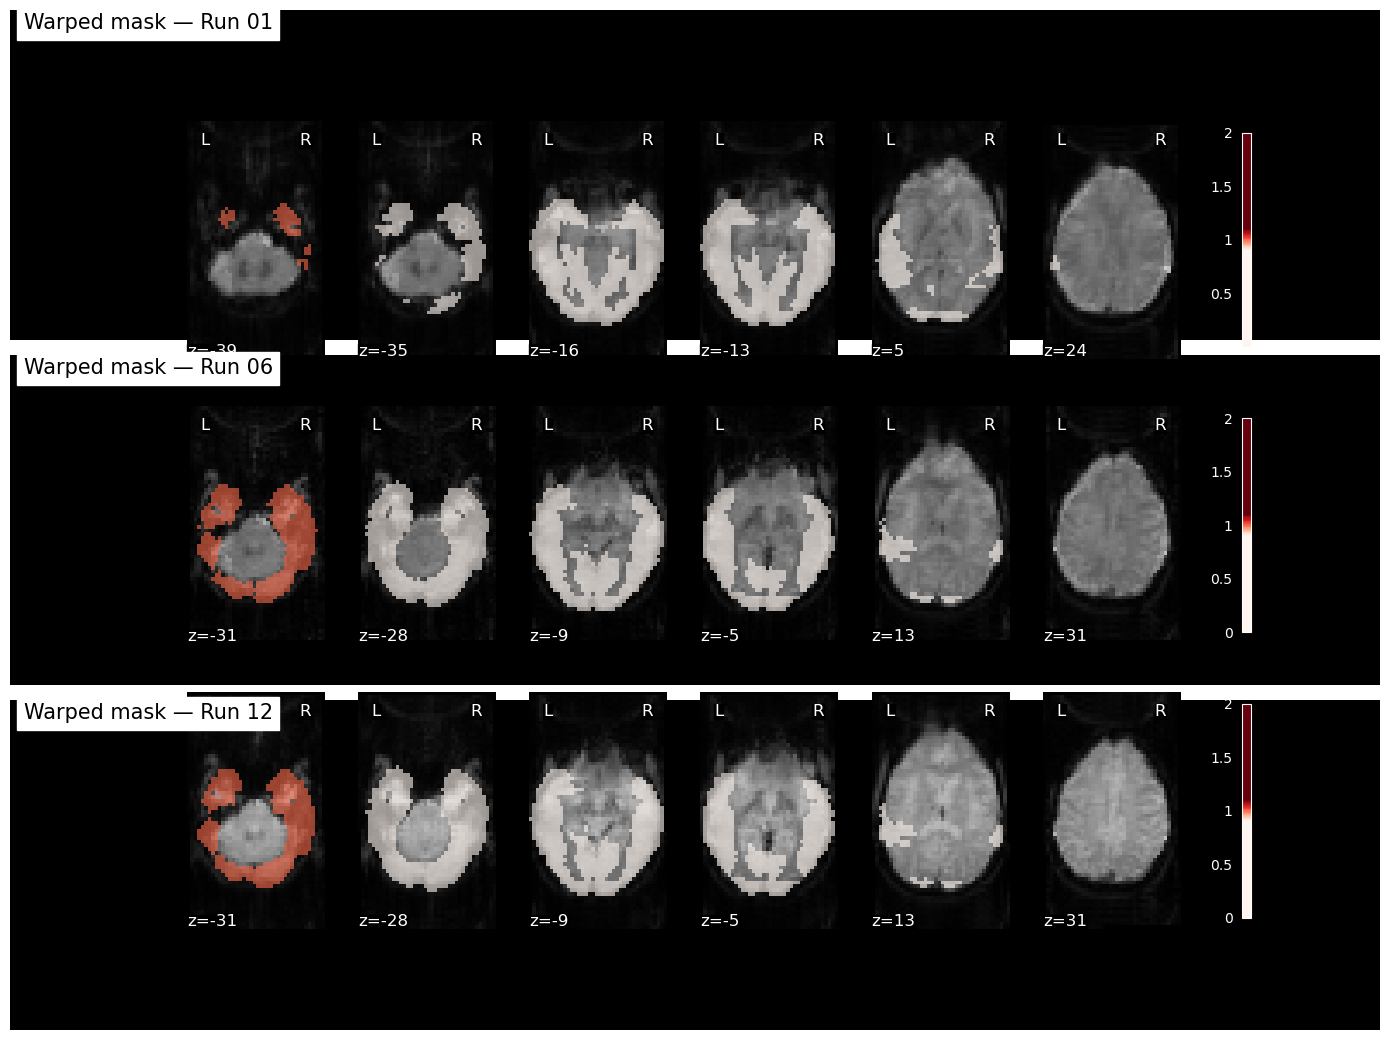

In [5]:
# Quick-look: overlay warped masks for runs 1, 6, 12 to check alignment.
# Small run-to-run differences are expected due to per-run BBR alignment.

check_runs = [1, 6, 12]
fig, axes = plt.subplots(len(check_runs), 1, figsize=(14, 3.5 * len(check_runs)))

for ax, run_id in zip(axes, check_runs):
    func_ref_img = image.load_img(func_ref_files[run_id - 1])
    plotting.plot_roi(
        warped_mask_imgs[run_id],
        bg_img=func_ref_img,
        display_mode='z',
        cut_coords=6,
        title=f'Warped mask — Run {run_id:02d}',
        alpha=0.6,
        cmap='Reds',
        axes=ax,
    )

plt.tight_layout()
plt.show()


In [7]:
# Remove voxels with near-zero temporal variance.
# Such voxels carry no signal and can cause numerical instability in the SVM.
# We apply variance filtering independently per run, then take the INTERSECTION
# across runs to ensure a consistent feature space for cross-validation.

# Paths to the BOLD files for variance estimation

filtered_masks = {}
for run_id, (bold_path, mask_img) in enumerate(
        zip(bold_paths, warped_mask_imgs.values()), start=1):

    if os.path.exists(bold_path):
        bold_img = image.load_img(bold_path)
        filtered, n_removed = filter_mask_by_variance(
            warped_mask_img=mask_img,
            bold_img=bold_img,
            var_threshold=1e-6,
        )
        filtered_masks[run_id] = filtered
        print(f"  Run {run_id:02d}: removed {n_removed} zero-variance voxels")
    else:
        # If BOLD not available, keep the warped mask as-is
        filtered_masks[run_id] = mask_img
        print(f"  Run {run_id:02d}: BOLD not found, using unfiltered mask")

# Build a COMMON mask = intersection across all runs
mask_data_stack = np.stack(
    [m.get_fdata().astype(bool) for m in filtered_masks.values()], axis=-1)
common_mask_data = mask_data_stack.all(axis=-1).astype(np.uint8)
ref_img = list(filtered_masks.values())[0]
mask_img = nib.Nifti1Image(common_mask_data, ref_img.affine, ref_img.header)

n_common = int(common_mask_data.sum())
print(f"\nCommon mask voxels (intersection across all runs): {n_common:,}")


  Run 01: BOLD not found, using unfiltered mask
  Run 02: BOLD not found, using unfiltered mask
  Run 03: BOLD not found, using unfiltered mask
  Run 04: BOLD not found, using unfiltered mask
  Run 05: BOLD not found, using unfiltered mask
  Run 06: BOLD not found, using unfiltered mask
  Run 07: BOLD not found, using unfiltered mask
  Run 08: BOLD not found, using unfiltered mask
  Run 09: BOLD not found, using unfiltered mask
  Run 10: removed 0 zero-variance voxels
  Run 11: removed 0 zero-variance voxels
  Run 12: removed 0 zero-variance voxels

Common mask voxels (intersection across all runs): 6,152


In [8]:
# Save the per-run filtered masks and the common intersection mask.

for run_id, mask in filtered_masks.items():
    out_path = os.path.join(
        WARPED_DIR,
        f"{SUBJECT}_task-objectviewing_run-{run_id:02d}_desc-warpedGroupMask_funcspace.nii.gz"
    )
    mask.to_filename(out_path)

common_path = os.path.join(
    WARPED_DIR,
    f"{SUBJECT}_task-objectviewing_desc-warpedGroupMaskCommon_funcspace.nii.gz"
)
mask_img.to_filename(common_path)

print(f"Saved {N_RUNS} per-run masks to: {WARPED_DIR}")
print(f"Saved common mask ({n_common:,} voxels) to: {common_path}")


Saved 12 per-run masks to: /scratch/alpine/amhe4269/mvpa_workshop/ds000105/derivatives/beta_weights/sub-1/warped_masks
Saved common mask (6,152 voxels) to: /scratch/alpine/amhe4269/mvpa_workshop/ds000105/derivatives/beta_weights/sub-1/warped_masks/sub-1_task-objectviewing_desc-warpedGroupMaskCommon_funcspace.nii.gz


---
## Next Steps

The per-run filtered masks and the common intersection mask have been saved to:

```
{WARPED_DIR}/
    {SUBJECT}_task-objectviewing_run-XX_desc-warpedGroupMask_funcspace.nii.gz  (12 files)
    {SUBJECT}_task-objectviewing_desc-warpedGroupMaskCommon_funcspace.nii.gz   (intersection)
```

**Proceed to Tutorial 3b** (`tutorial_03b_mvpa_decoding.ipynb`) to load the
beta-weight matrix, run SVM cross-validation, and generate importance maps.
The variable `common_path` printed above is the mask path you need for 3b.


---
## Summary

| Step | Tool | Output |
|---|---|---|
| ANTs availability check | `import ants` | `ANTS_AVAILABLE` flag |
| Per-run warp | `warp_group_mask_to_func()` | 12 binary masks in func space |
| QC visualisation | `nilearn.plotting.plot_roi()` | Overlay on boldref |
| Variance filtering | `filter_mask_by_variance()` | Removes zero-std voxels |
| Intersection mask | NumPy `all(axis=-1)` | Single mask spanning all runs |
| Save to disk | `nib.Nifti1Image.to_filename()` | Files for Tutorial 3b |
